In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import Ridge


In [13]:
df = pd.read_csv("diamonds.csv")
df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [14]:
## Drop index, unnecessary data
df = df.drop(columns=["Unnamed: 0"])

In [ ]:
## Check what kind of data and if we have missing values.
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.7 MB


carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [ ]:
## Dimensions cant be 0 so we check if there are any values that are 0.
(df[['x','y','z']] == 0).sum()

x     8
y     7
z    20
dtype: int64

In [ ]:
## filter out the ones with either x y or z that has 0
df = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)]

In [19]:
(df[['x','y','z']] == 0).sum()

x    0
y    0
z    0
dtype: int64

In [20]:
## encode so we transform the categorical data
df = pd.get_dummies(df, drop_first=True)

In [ ]:
## Split X and y
X = df.drop(columns=["price"])
y = df["price"]

In [ ]:
## Train/test split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
# Initialize model, train it and test it and check the rmse 
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
print("Linear RMSE:", rmse_lr)

Linear RMSE: 1135.9437162763488


In [30]:
## Since we have alot of features i will also train ridge model to lower the risk for overfitting
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

rmse_ridge = root_mean_squared_error(y_test, y_pred_ridge)
print("Ridge RMSE:", rmse_ridge)

Ridge RMSE: 1133.9764897675823


In [32]:
if rmse_lr < rmse_ridge:
    print("Linear Regression performs best")
else:
    print("Ridge Regression performs best")

Ridge Regression performs best


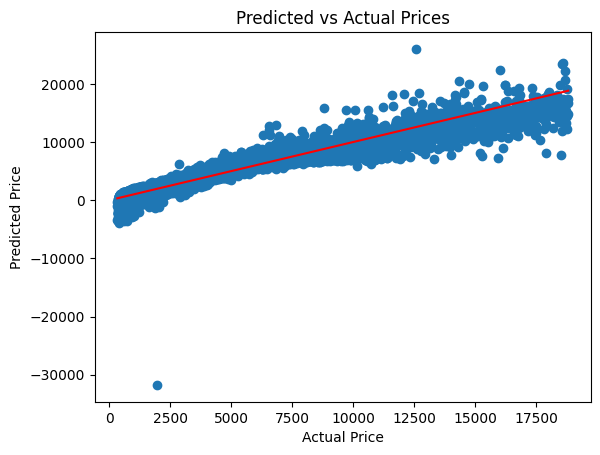

In [33]:
plt.scatter(y_test, y_pred_ridge)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices")
plt.show()